In [40]:
import json
import os

os.environ["SPS_HOME"] = "/Users/z5114326/Documents/GitHub/python-fsps/src/fsps/libfsps"

import dynesty
import fsps
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fsps.filters import FILTERS
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.stats import norm
from sklearn.mixture import GaussianMixture


In [3]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_dir = "/Users/z5114326/Documents/simulations/"

band_type = "SDSS"  # "SDSS" or "JC"
bands = ["sdss_g", "sdss_z"]
# bands = ["v"]

snap = 600
min_mass = 1e4

In [4]:
compute_vega_mags = band_type == "JC"

sp = fsps.StellarPopulation(
    imf_type=2,
    zcontinuous=1,
    compute_vega_mags=compute_vega_mags,
)

sp.params["add_dust_emission"] = False
sp.params["add_neb_continuum"] = False
sp.params["add_neb_emission"] = False
sp.params["add_agb_dust_model"] = False
sp.params["dust1"] = 0.0
sp.params["dust2"] = 0.0
sp.params["fcstar"] = 0.0
sp.params["agb_dust"] = 0.0
sp.params["tpagb_norm_type"] = 0

In [5]:
public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])
pub_snaps = np.array(pub_data["index"])

all_data_fil = sim_dir + "/" + "m12i" + "/" + "m12i" + "_res7100/" + "snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
all_times = np.array(all_data["time_Gyr"])
all_snaps = np.array(all_data["index"])

snap_times = {
    gc_utils.snapshot_name(s): float(pub_data.loc[pub_data["index"] == s, "time_Gyr"].values[0])
    for s in pub_snaps
}

In [6]:
sim_dict = {}

# ------------------------------------------------
# precompute snapshot times once
# ------------------------------------------------
snap_times = {
    gc_utils.snapshot_name(s): float(pub_data.loc[pub_data["index"] == s, "time_Gyr"].values[0])
    for s in pub_snaps
}

timez0 = snap_times[gc_utils.snapshot_name(snap)]

for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    sim_dict[sim] = {}

    with h5py.File(ghost_file, "r") as ghost_data:
        for it_id, it_grp in ghost_data.items():
            src = it_grp["source"]

            # ---------------------------
            # read once
            # ---------------------------
            grpid = src["grpid"][()]
            amsk = grpid == 0

            logm_tfor = src["logm_tfor"][()]
            logm_tz0 = src["logm_tz0"][()]

            m_tfo = 10.0**logm_tfor
            m_tfo_ev = 0.55 * m_tfo  # stellar-evolution corrected mass

            m_tz0 = np.zeros_like(logm_tz0, dtype=float)
            msk = logm_tz0 != -1
            m_tz0[msk] = 10.0 ** logm_tz0[msk]

            tfor = src["tfor"][()]
            tdis = src["tdis"][()]
            tacc = src["tacc"][()]
            feh = src["feh"][()]
            gcids = src["gcid"][()]

            tdis = np.where(tdis == -1, np.inf, tdis)

            rz0 = np.linalg.norm(src["pxyz_snap600"][()], axis=1)

            # ---------------------------
            # vectorized ages
            # ---------------------------
            age = timez0 - tfor
            age_p = np.where(np.isfinite(tdis), tdis - tfor, age)

            t_tz0 = src["torb_600"][()]
            s_tz0 = src["s_flag"][()].astype(bool)
            sa_flag = src["sa_flag"][()].astype(bool)

            # ---------------------------
            # snapshot mass table
            #   + tfor (m_tfo_ev)
            #   + tdis (0)
            # ---------------------------
            n_gc = len(gcids)
            n_snap = len(pub_snaps)

            mass_arr = np.full((n_gc, n_snap + 2), np.nan)
            time_arr = np.full((n_gc, n_snap + 2), np.nan)

            # ---- formation point ----
            mass_arr[:, 0] = m_tfo_ev
            time_arr[:, 0] = tfor

            # ---- simulation snapshots ----
            for j, (snap_id, time) in enumerate(snap_times.items(), start=1):
                snp = it_grp["snapshots"][snap_id]
                snp_gcids = snp["gcid"][()]
                snp_mass = 10.0 ** snp["logm"][()]

                common, idx_snp, idx_src = np.intersect1d(snp_gcids, gcids, return_indices=True)

                mass_arr[idx_src, j] = snp_mass[idx_snp]
                time_arr[idx_src, j] = time

                # ---- disruption point (only if disrupted) ----
                has_disrupted = np.isfinite(tdis)

                mass_arr[has_disrupted, -1] = 0.0
                time_arr[has_disrupted, -1] = tdis[has_disrupted]

            # ---------------------------
            # final mass cut
            # ---------------------------
            m_tfo_msk = m_tfo >= min_mass

            sim_dict[sim][it_id] = {
                "gcid": gcids[m_tfo_msk],
                "feh": feh[m_tfo_msk],
                "tfor": tfor[m_tfo_msk],
                "tdis": tdis[m_tfo_msk],
                "tacc": tacc[m_tfo_msk],
                "age": age[m_tfo_msk],
                "age_p": age_p[m_tfo_msk],
                "rz0": rz0[m_tfo_msk],
                "t_tz0": t_tz0[m_tfo_msk],
                "s_tz0": s_tz0[m_tfo_msk],
                "sa_flag": sa_flag[m_tfo_msk],
                "acc": amsk[m_tfo_msk],
                # ---- masses ----
                "m_tfo": m_tfo[m_tfo_msk],
                "m_tfo_ev": m_tfo_ev[m_tfo_msk],
                "m_tz0": m_tz0[m_tfo_msk],
                # ---- time-resolved mass history ----
                "m_snp": mass_arr[m_tfo_msk],
                "t_snp": time_arr[m_tfo_msk],
            }

In [7]:
def build_mass_interpolators(dat):
    interps = []

    for m, t in zip(dat["m_snp"], dat["t_snp"]):
        msk = np.isfinite(m) & (m > 0)
        if np.sum(msk) < 2:
            interps.append(None)
            continue

        order = np.argsort(t[msk])
        ts = t[msk][order]
        ms = m[msk][order]

        interps.append(interp1d(ts, ms, kind="linear", bounds_error=False, fill_value=(ms[0], 0.0)))

    return interps


for sim in sim_lst:
    for it_id in sim_dict[sim]:
        sim_dict[sim][it_id]["mass_interp"] = build_mass_interpolators(sim_dict[sim][it_id])

In [8]:
# ============================================================
# BUILD TIME-DEPENDENT GC MAGNITUDES INTO ssp_dict
# ============================================================

sim_lst = ["m12i"]
tims = np.arange(0.4, 14, 0.2)  # DO NOT CHANGE THIS PLEASE

print("\n================ BUILDING ssp_dict ================\n")

bands_tag = "_".join(bands)
n_band = len(bands)

ssp_dict = {}

for sim in sim_lst:
    print(f"[SIM] {sim}")

    # --------------------------------------------------------
    # Collect (age, feh) pairs needed for THIS SIM
    # --------------------------------------------------------
    ages_all = []
    fehs_all = []

    for it_id, dat in sim_dict[sim].items():
        tfor = dat["tfor"]
        feh = dat["feh"]

        for t in tims:
            age_t = t - tfor
            msk = age_t > 0
            if np.any(msk):
                ages_all.append(age_t[msk])
                fehs_all.append(feh[msk])

    ages_all = np.concatenate(ages_all)
    fehs_all = np.concatenate(fehs_all)

    ssp_params = np.column_stack((ages_all, fehs_all))
    unique_ssps = np.unique(ssp_params, axis=0)

    print(f"Unique SSPs needed: {len(unique_ssps)}")

    # --------------------------------------------------------
    # FSPS cache (per sim, per band system)
    # --------------------------------------------------------
    cache_dir = f"../data/ssp_caches/{sim}"
    os.makedirs(cache_dir, exist_ok=True)
    cache_path = f"{cache_dir}/ssp_{band_type}_{bands_tag}.npz"

    if os.path.exists(cache_path):
        print("  → Loading FSPS cache")
        cache = np.load(cache_path)
        ssp_mag = cache["ssp_mag"]
        ssp_mass = cache["ssp_mass"]
        cached_ssps = cache["unique_ssps"]

        if not np.array_equal(cached_ssps, unique_ssps):
            print("SSP grid mismatch — recomputing")
            recompute = True
        else:
            recompute = False
    else:
        recompute = True

    if recompute:
        print("Computing FSPS SSP grid")
        n_ssp = len(unique_ssps)

        ssp_mag = np.empty((n_ssp, n_band))
        ssp_mass = np.empty(n_ssp)

        for i, (age, feh) in enumerate(unique_ssps):
            if i % 100 == 0 or i == n_ssp - 1:
                print(f"    SSP {i + 1}/{n_ssp}")

            sp.params["logzsol"] = feh
            ssp_mag[i] = sp.get_mags(tage=age, bands=bands)
            ssp_mass[i] = sp.stellar_mass

        np.savez(
            cache_path,
            unique_ssps=unique_ssps,
            ssp_mag=ssp_mag,
            ssp_mass=ssp_mass,
        )

    # --------------------------------------------------------
    # Build fast lookup: (age, feh) -> SSP index
    # --------------------------------------------------------
    ssp_lookup = {(unique_ssps[i, 0], unique_ssps[i, 1]): i for i in range(len(unique_ssps))}

    # --------------------------------------------------------
    # Allocate output dictionary for this sim
    # --------------------------------------------------------
    ssp_dict[sim] = {"times": np.asarray(tims)}

    # --------------------------------------------------------
    # Compute magnitudes for each it_id
    # --------------------------------------------------------
    for it_id, dat in sim_dict[sim].items():
        print(f"    [ITER] {it_id}")

        gcids = dat["gcid"]
        tfor = dat["tfor"]
        feh = dat["feh"]
        tdis = dat["tdis"]
        tacc = dat["tacc"]
        mass_interp = dat["mass_interp"]

        n_gc = len(gcids)
        n_t = len(tims)

        mags = np.full((n_gc, n_t, n_band), np.nan, dtype=float)

        for ti, t in enumerate(tims):
            alive = (tfor <= t) & (t < tdis) & (tacc <= t)

            for i in np.where(alive)[0]:
                fmass = mass_interp[i]
                if fmass is None:
                    continue

                m_now = float(fmass(t))
                if m_now <= 0:
                    continue

                age = t - tfor[i]
                if age <= 0:
                    continue

                ssp_idx = ssp_lookup.get((age, feh[i]))
                if ssp_idx is None:
                    continue

                mags[i, ti, :] = ssp_mag[ssp_idx] - 2.5 * np.log10(m_now / ssp_mass[ssp_idx])

        ssp_dict[sim][it_id] = {
            "gcid": gcids,
            "mags": mags,  # (N_gc, N_time, N_band)
        }

print("\n================ ssp_dict COMPLETE ================\n")


================ BUILDING ssp_dict ================

[SIM] m12i
Unique SSPs needed: 5595775
  → Loading FSPS cache
    [ITER] it000
    [ITER] it001
    [ITER] it003
    [ITER] it004
    [ITER] it005
    [ITER] it006
    [ITER] it008
    [ITER] it009
    [ITER] it010
    [ITER] it011
    [ITER] it012
    [ITER] it013
    [ITER] it014
    [ITER] it015
    [ITER] it016
    [ITER] it017
    [ITER] it018
    [ITER] it019
    [ITER] it020
    [ITER] it021
    [ITER] it022
    [ITER] it023
    [ITER] it024
    [ITER] it025
    [ITER] it026
    [ITER] it027
    [ITER] it028
    [ITER] it029
    [ITER] it031
    [ITER] it032
    [ITER] it033
    [ITER] it034
    [ITER] it036
    [ITER] it037
    [ITER] it038
    [ITER] it039
    [ITER] it040
    [ITER] it041
    [ITER] it042
    [ITER] it043
    [ITER] it044
    [ITER] it045
    [ITER] it046
    [ITER] it047
    [ITER] it048
    [ITER] it049
    [ITER] it050
    [ITER] it051
    [ITER] it052
    [ITER] it053
    [ITER] it054
    [ITER] it055


In [9]:
def gif_wrapping(
    plot_func,
    param_name,
    param_values,
    gif_path,
    fixed_kwargs=None,
    interval=200,
    dpi=150,
    figsize=(8, 6),
):
    """
    Generic animation wrapper.
    """

    fixed_kwargs = fixed_kwargs or {}

    fig, ax = plt.subplots(figsize=figsize)

    def update(value):
        kwargs = fixed_kwargs.copy()
        kwargs[param_name] = value
        plot_func(ax=ax, **kwargs)
        return (ax,)

    anim = FuncAnimation(fig, update, frames=param_values, interval=interval, blit=False)

    anim.save(gif_path, writer=PillowWriter(fps=1000 // interval), dpi=dpi)
    plt.close(fig)

In [10]:
def cols_hist(ax, sim, ssp_dict, tim):
    ax.clear()
    bins = np.arange(-2, 2.1, 0.1)

    hist_dict = {"sum": None, "n": 0}

    tims = ssp_dict[sim]["times"]
    tidx = np.where(tims == tim)[0][0]
    for it_id in ssp_dict[sim].keys():
        # for it_id in ["it099"]:
        if it_id == "times":
            continue

        cols = []
        for mags_j in ssp_dict[sim][it_id]["mags"]:
            col = mags_j[tidx][0] - mags_j[tidx][1]
            cols.append(col)
        cols = np.asarray(cols)
        hssp, _ = np.histogram(cols, bins=bins)

        if hist_dict["sum"] is None:
            hist_dict["sum"] = hssp.astype(float)
        else:
            hist_dict["sum"] += hssp

        hist_dict["n"] += 1

    # bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # widths = bins[1:] - bins[:-1]

    binsum = hist_dict["sum"] / hist_dict["n"]

    ax.step(bins[:-1], binsum, where="post", color="k")
    # ax.fill_between(bins[:-1], binsum, step="post", alpha=0.5, color="r")

    ax.set_xlabel(r"(g - z)$_{0}$")
    ax.set_ylabel("Number")

    ax.set_xlim(-2, 2)
    ax.set_ylim(0)

    text = sim + "\n" + "t = " + str(np.round(tim, 2)) + " Gyr"

    ax.text(
        0.04,
        0.94,
        text,
        transform=ax.transAxes,
        color="k",
        ha="left",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="white",
        ),
    )

In [11]:
tims

array([ 0.4,  0.6,  0.8,  1. ,  1.2,  1.4,  1.6,  1.8,  2. ,  2.2,  2.4,
        2.6,  2.8,  3. ,  3.2,  3.4,  3.6,  3.8,  4. ,  4.2,  4.4,  4.6,
        4.8,  5. ,  5.2,  5.4,  5.6,  5.8,  6. ,  6.2,  6.4,  6.6,  6.8,
        7. ,  7.2,  7.4,  7.6,  7.8,  8. ,  8.2,  8.4,  8.6,  8.8,  9. ,
        9.2,  9.4,  9.6,  9.8, 10. , 10.2, 10.4, 10.6, 10.8, 11. , 11.2,
       11.4, 11.6, 11.8, 12. , 12.2, 12.4, 12.6, 12.8, 13. , 13.2, 13.4,
       13.6, 13.8])

In [13]:
run_gif = False

if run_gif:
    gif_path = "../data/results/" + sim + "_tcolor.gif"
    gif_wrapping(
        plot_func=cols_hist,
        param_name="tim",
        param_values=tims,
        gif_path=gif_path,
        fixed_kwargs=dict(sim=sim, ssp_dict=ssp_dict),
        interval=250,
    )

# BEST FITS?

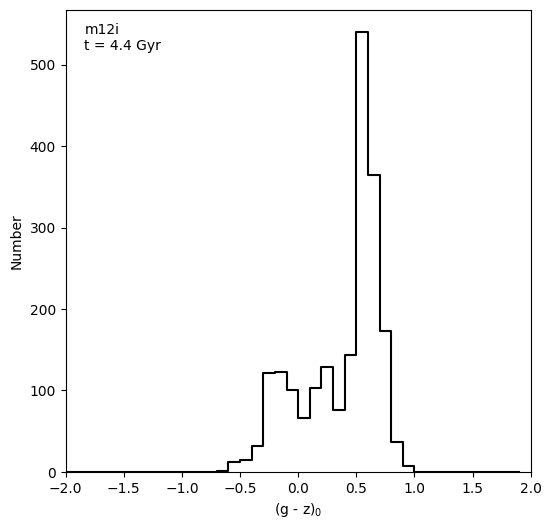

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

tim = tims[20]
cols_hist(ax, sim, ssp_dict, tim)

In [48]:
# Select time
tim = tims[20]

tims_arr = ssp_dict[sim]["times"]
tidx = np.where(tims_arr == tim)[0][0]

# Collect colours PER realisation
all_cols = []

for it_id in ssp_dict[sim].keys():
    if it_id == "times":
        continue

    cols = []
    for mags_j in ssp_dict[sim][it_id]["mags"]:
        g = mags_j[tidx][0]
        z = mags_j[tidx][1]

        # Drop NaNs safely
        if np.isfinite(g) and np.isfinite(z):
            cols.append(g - z)

    cols = np.asarray(cols)

    # Only keep realisations with at least 2 points
    if len(cols) > 1:
        all_cols.append(cols)

R = len(all_cols)  # number of realisations
print(f"{R} realisations loaded")

100 realisations loaded


In [49]:
def gmm_loglike_avg(theta, all_cols, K):
    """
    Averaged log-likelihood across realisations.
    """
    logw = theta[:K]
    mus = theta[K : 2 * K]
    logsig = theta[2 * K : 3 * K]

    w = np.exp(logw)
    w /= np.sum(w)
    sig = np.exp(logsig)

    logL = 0.0

    for x in all_cols:
        logp = []
        for k in range(K):
            logp.append(np.log(w[k]) + norm.logpdf(x, mus[k], sig[k]))

        # Mean log-likelihood for this realisation
        logL += np.mean(logsumexp(logp, axis=0))

    return logL


def prior_transform(u, K, xmin, xmax):
    theta = np.zeros(3 * K)

    # Mixture weights (log-space)
    theta[:K] = np.log(u[:K] + 1e-12)

    # Means: uniform over data range
    theta[K : 2 * K] = xmin + u[K : 2 * K] * (xmax - xmin)

    # Sigmas: log-uniform
    theta[2 * K : 3 * K] = np.log(0.01 + u[2 * K : 3 * K] * 1.0)

    return theta


def bic_avg(logL, K, R):
    """
    BIC for averaged likelihood.
    """
    p = 3 * K - 1
    return -2 * logL + p * np.log(R)

In [50]:
# Pooled data ONLY for numerical initialisation
x_pool = np.concatenate(all_cols).reshape(-1, 1)


In [52]:
Ks = range(1, 4)
bic_vals = []

for K in Ks:
    # Initialisation via pooled GMM
    gmm = GaussianMixture(n_components=K, n_init=10, random_state=42)
    gmm.fit(x_pool)

    theta0 = np.zeros(3 * K)
    theta0[:K] = np.log(gmm.weights_)
    theta0[K : 2 * K] = gmm.means_.flatten()
    theta0[2 * K : 3 * K] = np.log(np.sqrt(gmm.covariances_.flatten()))

    res = minimize(lambda th: -gmm_loglike_avg(th, all_cols, K), theta0, method="Powell")

    logL = -res.fun
    bic = bic_avg(logL, K, R)
    bic_vals.append(bic)

    print(f"K={K}, logL={logL:.2f}, BIC={bic:.2f}")


K=1, logL=-32.27, BIC=73.75
K=2, logL=-3.38, BIC=29.78
K=3, logL=-0.52, BIC=37.88


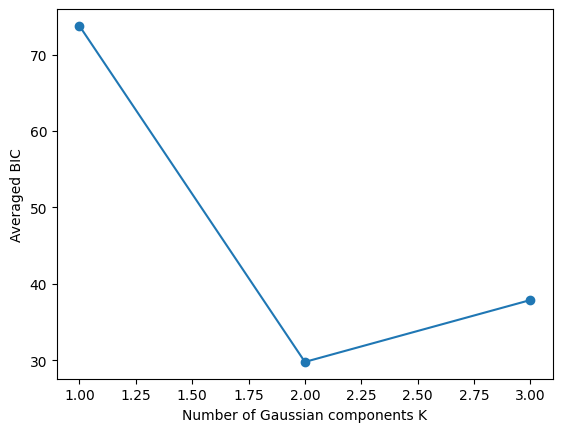

In [53]:
plt.plot(Ks, bic_vals, marker="o")
plt.xlabel("Number of Gaussian components K")
plt.ylabel("Averaged BIC")
plt.show()

In [54]:
best_bic_K = Ks[np.argmin(bic_vals)]
candidate_Ks = [K for K in [best_bic_K - 1, best_bic_K, best_bic_K + 1] if K >= 1]

print("Candidate K values:", candidate_Ks)

Candidate K values: [1, 2, 3]


In [55]:
def run_nested_avg(K, all_cols, nlive=1000):
    xmin = min(np.min(x) for x in all_cols)
    xmax = max(np.max(x) for x in all_cols)

    sampler = dynesty.NestedSampler(
        lambda th: gmm_loglike_avg(th, all_cols, K),
        lambda u: prior_transform(u, K, xmin, xmax),
        ndim=3 * K,
        nlive=nlive,
        bound="multi",
        sample="rwalk",
    )

    sampler.run_nested(print_progress=False)
    res = sampler.results
    return res.logz[-1], res.logzerr[-1]

In [56]:
evidence = {}

for K in candidate_Ks:
    logZ, dlogZ = run_nested_avg(K, all_cols, nlive=10)
    # logZ, dlogZ = run_nested_avg(K, all_cols, nlive=1000)
    evidence[K] = (logZ, dlogZ)
    print(f"K={K}: logZ = {logZ:.2f} ± {dlogZ:.2f}")

K=1: logZ = -37.96 ± 0.68


/Users/z5114326/Documents/GitHub/ghost_accretions/.venv/lib/python3.11/site-packages/dynesty/dynesty.py:518: UserWarning: Beware! Having `nlive <= 2 * ndim` is extremely risky!
  warnings.warn("Beware! Having `nlive <= 2 * ndim` is extremely risky!")


K=2: logZ = -16.07 ± 0.94


/Users/z5114326/Documents/GitHub/ghost_accretions/.venv/lib/python3.11/site-packages/dynesty/dynesty.py:518: UserWarning: Beware! Having `nlive <= 2 * ndim` is extremely risky!
  warnings.warn("Beware! Having `nlive <= 2 * ndim` is extremely risky!")


K=3: logZ = -19.71 ± 1.03


In [57]:
# Reference model: highest evidence
K_ref = max(evidence, key=lambda k: evidence[k][0])

# Evidence differences
delta_logZ = {}
for K in evidence:
    dlogZ = evidence[K][0] - evidence[K_ref][0]
    delta_logZ[K] = dlogZ
    print(f"ΔlogZ(K={K} vs K={K_ref}) = {dlogZ:.2f}")

ΔlogZ(K=1 vs K=2) = -21.90
ΔlogZ(K=2 vs K=2) = 0.00
ΔlogZ(K=3 vs K=2) = -3.64


In [58]:
DELTA_LOGZ_STRONG = 5.0  # Jeffreys scale

Kbest = min(K for K, dlogZ in delta_logZ.items() if dlogZ >= -DELTA_LOGZ_STRONG)

print(f"\nChosen Kbest = {Kbest}")


Chosen Kbest = 2


In [59]:
# pooled data ONLY for initialisation
x_pool = np.concatenate(all_cols).reshape(-1, 1)

gmm = GaussianMixture(n_components=Kbest, n_init=10, random_state=42)
gmm.fit(x_pool)

theta0 = np.zeros(3 * Kbest)
theta0[:Kbest] = np.log(gmm.weights_)
theta0[Kbest : 2 * Kbest] = gmm.means_.flatten()
theta0[2 * Kbest : 3 * Kbest] = np.log(np.sqrt(gmm.covariances_.flatten()))


In [60]:
res = minimize(lambda th: -gmm_loglike_avg(th, all_cols, Kbest), theta0, method="Powell")

theta_best = res.x

In [61]:
bins = np.arange(-2.0, 2.1, 0.1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

hist_sum = None
for cols in all_cols:
    h, _ = np.histogram(cols, bins=bins)
    if hist_sum is None:
        hist_sum = h.astype(float)
    else:
        hist_sum += h

binsum = hist_sum / len(all_cols)  # mean over realisations

In [62]:
K = Kbest

logw = theta_best[:K]
mus = theta_best[K : 2 * K]
sig = np.exp(theta_best[2 * K : 3 * K])

w = np.exp(logw)
w /= np.sum(w)

x_plot = np.linspace(bins.min(), bins.max(), 1000)

pdf_total = np.zeros_like(x_plot)
pdf_components = []

for k in range(K):
    pdf_k = w[k] * norm.pdf(x_plot, mus[k], sig[k])
    pdf_components.append(pdf_k)
    pdf_total += pdf_k

In [63]:
bin_width = bins[1] - bins[0]
mean_ngc = np.mean([len(c) for c in all_cols])

model_counts = pdf_total * bin_width * mean_ngc

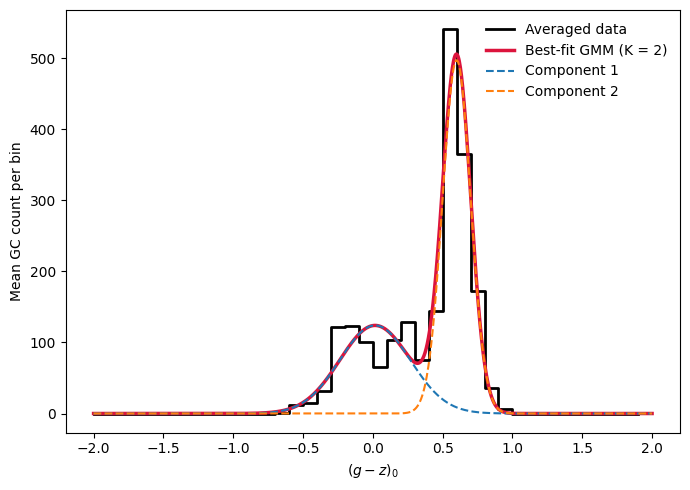

In [64]:
plt.figure(figsize=(7, 5))

# Averaged data
plt.step(bins[:-1], binsum, where="post", color="k", linewidth=2, label="Averaged data")

# Best-fit GMM
plt.plot(x_plot, model_counts, color="crimson", linewidth=2.5, label=f"Best-fit GMM (K = {Kbest})")

# Individual components (optional but informative)
for k, pdf_k in enumerate(pdf_components):
    plt.plot(x_plot, pdf_k * bin_width * mean_ngc, linestyle="--", linewidth=1.5, label=f"Component {k + 1}")

plt.xlabel(r"$(g - z)_0$")
plt.ylabel("Mean GC count per bin")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Loaded 100 realisations
K=1, BIC=-32502.54
K=2, BIC=-35737.97
K=3, BIC=-35445.24

GC colour population is classified as: BIMODAL


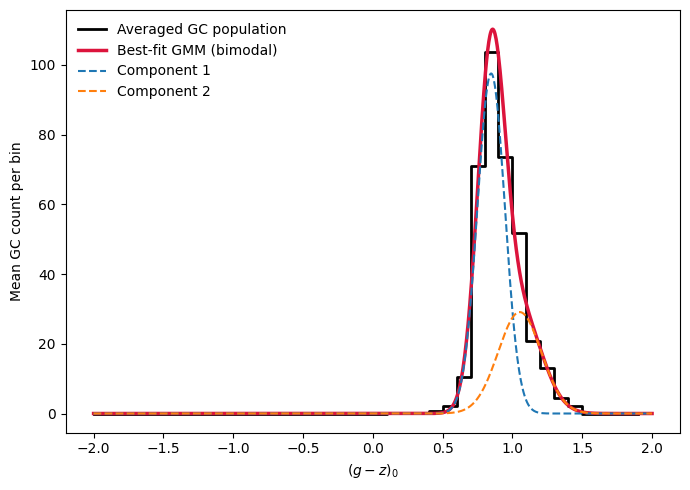

In [66]:
# ============================================================
# GC COLOUR POPULATION STRUCTURE AT A GIVEN SNAPSHOT
# ------------------------------------------------------------
# This script:
#  1) Averages GC colour distributions across stochastic realisations
#  2) Fits GMMs with K=1,2,3 components
#  3) Uses BIC to identify unimodal / bimodal / trimodal structure
#  4) Plots averaged data + best-fit model
# ============================================================


# -------------------------------
# USER INPUTS
# -------------------------------

sim = "m12i"
tim_index = 50  # snapshot index
bins = np.arange(-2.0, 2.1, 0.1)  # colour bins
K_test = [1, 2, 3]  # complexity to test
BIC_THRESHOLD = 6.0  # standard strong-evidence threshold

# -------------------------------
# 1. EXTRACT GC COLOURS
#    (per realisation, NaN-safe)
# -------------------------------

tims = ssp_dict[sim]["times"]
tidx = tim_index

all_cols = []

for it_id in ssp_dict[sim]:
    if it_id == "times":
        continue

    cols = []
    for mags_j in ssp_dict[sim][it_id]["mags"]:
        g = mags_j[tidx][0]
        z = mags_j[tidx][1]

        # Only keep physically meaningful measurements
        if np.isfinite(g) and np.isfinite(z):
            c = g - z
            if np.isfinite(c):
                cols.append(c)

    cols = np.asarray(cols)
    if cols.size >= 2:
        all_cols.append(cols)

R = len(all_cols)
if R < 5:
    raise RuntimeError("Not enough realisations for robust statistics")

print(f"Loaded {R} realisations")

# -------------------------------
# 2. AVERAGED HISTOGRAM
#    (what we plot & interpret)
# -------------------------------

hist_sum = np.zeros(len(bins) - 1)

for cols in all_cols:
    h, _ = np.histogram(cols, bins=bins)
    hist_sum += h

binsum = hist_sum / R
bin_centers = 0.5 * (bins[:-1] + bins[1:])
mean_ngc = np.mean([len(c) for c in all_cols])
bin_width = bins[1] - bins[0]

# -------------------------------
# 3. BIC-BASED STRUCTURE TEST
# -------------------------------

# Pool data ONLY for fitting convenience
x_pool = np.concatenate(all_cols).reshape(-1, 1)

bics = {}
gmms = {}

for K in K_test:
    gmm = GaussianMixture(n_components=K, covariance_type="full", n_init=20, random_state=42)
    gmm.fit(x_pool)
    bics[K] = gmm.bic(x_pool)
    gmms[K] = gmm
    print(f"K={K}, BIC={bics[K]:.2f}")

# -------------------------------
# 4. CLASSIFY STRUCTURE
# -------------------------------

# Start unimodal
structure = "unimodal"
Kbest = 1

if (bics[1] - bics[2]) >= BIC_THRESHOLD:
    structure = "bimodal"
    Kbest = 2

if 2 in bics and 3 in bics and (bics[2] - bics[3]) >= BIC_THRESHOLD:
    structure = "trimodal"
    Kbest = 3

print(f"\nGC colour population is classified as: {structure.upper()}")

# -------------------------------
# 5. BUILD BEST-FIT MODEL CURVE
# -------------------------------

gmm = gmms[Kbest]
weights = gmm.weights_
means = gmm.means_.flatten()
sigmas = np.sqrt(gmm.covariances_.flatten())

x_plot = np.linspace(bins.min(), bins.max(), 1000)

pdf_total = np.zeros_like(x_plot)
pdf_components = []

for k in range(Kbest):
    pdf_k = weights[k] * norm.pdf(x_plot, means[k], sigmas[k])
    pdf_components.append(pdf_k)
    pdf_total += pdf_k

model_counts = pdf_total * bin_width * mean_ngc

# -------------------------------
# 6. FINAL PLOT
# -------------------------------

plt.figure(figsize=(7, 5))

# Averaged data
plt.step(bins[:-1], binsum, where="post", color="k", linewidth=2, label="Averaged GC population")

# Best-fit mixture
plt.plot(x_plot, model_counts, color="crimson", linewidth=2.5, label=f"Best-fit GMM ({structure})")

# Individual components
for k, pdf_k in enumerate(pdf_components):
    plt.plot(x_plot, pdf_k * bin_width * mean_ngc, linestyle="--", linewidth=1.5, label=f"Component {k + 1}")

plt.xlabel(r"$(g - z)_0$")
plt.ylabel("Mean GC count per bin")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# -------------------------------
# DONE
# -------------------------------